# §1 Individual (unfiltered) (v11)

Per-combo metrics and per-combo equity/drawdown curves on the
20% OOS test partition with no ML#2 filter. Two sizing policies
compared: `fixed_dollars_500` and `pct5_compound`.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd

REPO = Path.cwd().resolve()
while not (REPO / 'src').exists() and REPO.parent != REPO:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from scripts.evaluation._top_perf_common import (
    STARTING_EQUITY, RISK_FRAC, POLICIES,
    apply_sizing, metrics_from_pnl, monte_carlo,
    load_setup,
    plot_indiv_equity, plot_indiv_dd,
    plot_combined_equity, plot_combined_dd,
    plot_ml2_indiv_equity, plot_ml2_indiv_dd,
    plot_ml2_combined_equity, plot_ml2_combined_dd,
    plot_mc_sims, plot_mc_pnl, plot_mc_sharpe, plot_mc_dd,
)

_ctx = load_setup(cost_per_contract_rt=0.0, top_strategies_path=REPO / 'evaluation' / 'top_strategies_v11.json')
bars            = _ctx['bars']
YEARS_SPAN      = _ctx['years_span']
strategies      = _ctx['strategies']
results_raw     = _ctx['results_raw']
combined_raw    = _ctx['combined_raw']
combos_ml2      = _ctx['combos_ml2']
s4_pnl_by_combo = _ctx['s4_pnl_by_combo']
ml2_portfolio   = _ctx['ml2_portfolio']


Top-K source: top_strategies_v11.json


Test partition: 514,563 bars  2024-10-22 05:08:00 -> 2026-04-08 20:20:00
Years span: 1.461  (used to annualize Sharpe)
Loaded 10 strategies.
results_raw cache stale; rebuilding.
Running unfiltered composed_strategy_runner for each combo...


  v10_7877...


  v10_7716...


  v10_9017...


...

  Family A computed: prior_wr_10 mean=0.205, prior_wr_50 mean=0.215, has_history_50 rate=0.959
  Family A computed: prior_wr_10 mean=0.205, prior_wr_50 mean=0.215, has_history_50 rate=0.959
    n_trades=608  rr=4.38
  v10_8592...


  Family A computed: prior_wr_10 mean=0.131, prior_wr_50 mean=0.135, has_history_50 rate=0.964
  Family A computed: prior_wr_10 mean=0.131, prior_wr_50 mean=0.135, has_history_50 rate=0.964
    n_trades=700  rr=4.22
  v10_6378...


  Family A computed: prior_wr_10 mean=0.232, prior_wr_50 mean=0.258, has_history_50 rate=0.860
  Family A computed: prior_wr_10 mean=0.232, prior_wr_50 mean=0.258, has_history_50 rate=0.860
    n_trades=179  rr=3.01
  v10_7834...


  Family A computed: prior_wr_10 mean=0.365, prior_wr_50 mean=0.375, has_history_50 rate=0.917
  Family A computed: prior_wr_10 mean=0.365, prior_wr_50 mean=0.375, has_history_50 rate=0.917
    n_trades=303  rr=3.14
  v10_608...


  Family A computed: prior_wr_10 mean=0.286, prior_wr_50 mean=0.295, has_history_50 rate=0.958
  Family A computed: prior_wr_10 mean=0.286, prior_wr_50 mean=0.295, has_history_50 rate=0.958
    n_trades=593  rr=2.07
Wrote cache -> _ml2_cache.pkl
ML2 portfolio trade counts: {'fixed_dollars_500': 658, 'pct5_compound': 658}


In [2]:
rows = []
for r in results_raw:
    if r['trades'].empty:
        for policy in POLICIES:
            rows.append({'combo_id': r['combo_id'], 'policy': policy,
                         **metrics_from_pnl(np.array([]), YEARS_SPAN, policy=policy)})
        continue
    t = r['trades'].sort_values('date', kind='mergesort')
    pnl_base = t['actual_pnl'].to_numpy(dtype=float)
    risk_base = t['dollar_risk'].to_numpy(dtype=float)
    r_mult = np.where(risk_base > 0, pnl_base / risk_base, 0.0)
    for policy in POLICIES:
        pnl = apply_sizing(pnl_base, risk_base, policy)
        rows.append({'combo_id': r['combo_id'], 'policy': policy,
                     **metrics_from_pnl(pnl, YEARS_SPAN, policy=policy, r=r_mult)})
perf1 = pd.DataFrame(rows)
perf1

,combo_id,policy,n_trades,trades_per_year,win_rate,total_pnl_dollars,total_return_pct,sharpe_ratio,max_drawdown_pct,max_drawdown_dollars
0,v10_7877,fixed_dollars_500,1616,1106.1,0.3676,28566.04,57.13,1.1415,18.71,14736.94
1,v10_7877,pct5_compound,1616,1106.1,0.3676,-2006.34,-4.01,-0.0119,90.52,349343.71
2,v10_7716,fixed_dollars_500,2059,1409.3,0.1321,-13722.39,-27.44,-0.3463,56.95,45008.93
3,v10_7716,pct5_compound,2059,1409.3,0.1321,-49960.82,-99.92,-1.7922,99.98,154462.65
4,v10_9017,fixed_dollars_500,1406,962.3,0.2226,20096.24,40.19,0.8561,26.87,19275.01
5,v10_9017,pct5_compound,1406,962.3,0.2226,-17195.38,-34.39,-0.1430,98.46,324922.59
6,v10_3616,fixed_dollars_500,1901,1301.2,0.3735,14677.88,29.36,0.5889,20.13,15549.61
7,v10_3616,pct5_compound,1901,1301.2,0.3735,-43284.98,-86.57,-0.5868,97.22,180255.54
8,v10_7872,fixed_dollars_500,930,636.5,0.1333,41220.76,82.44,1.7454,17.37,18596.11
9,v10_7872,pct5_compound,930,636.5,0.1333,505819.05,1011.64,0.7866,96.92,13995983.73


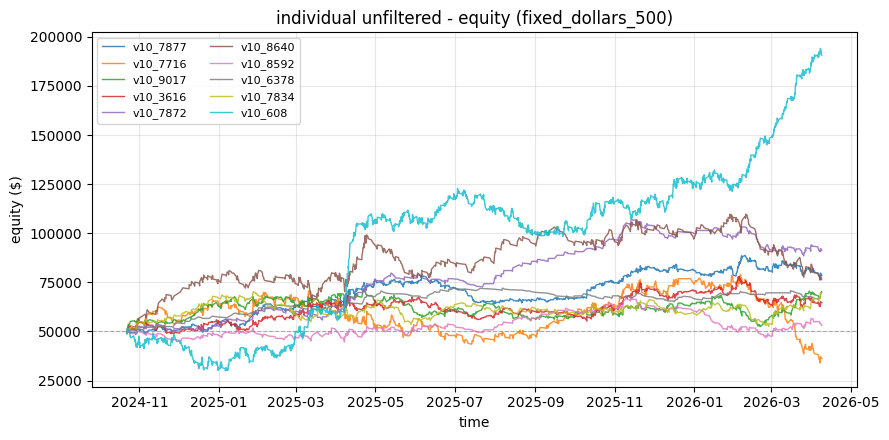

In [3]:
plot_indiv_equity(results_raw, 'fixed_dollars_500')

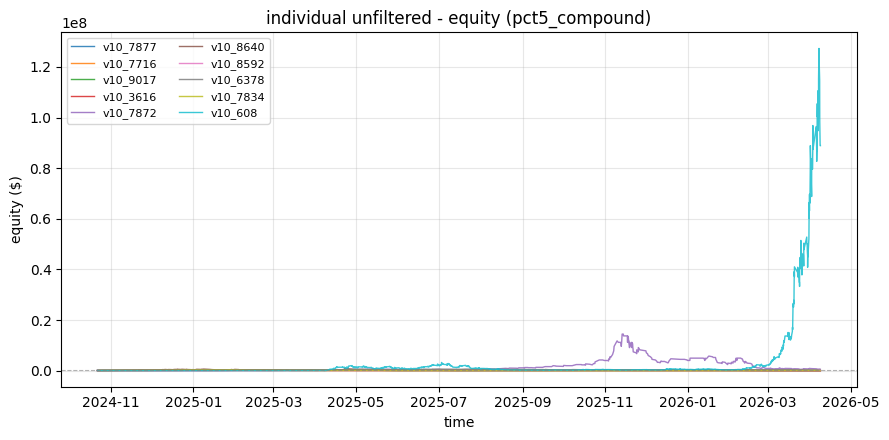

In [4]:
plot_indiv_equity(results_raw, 'pct5_compound')

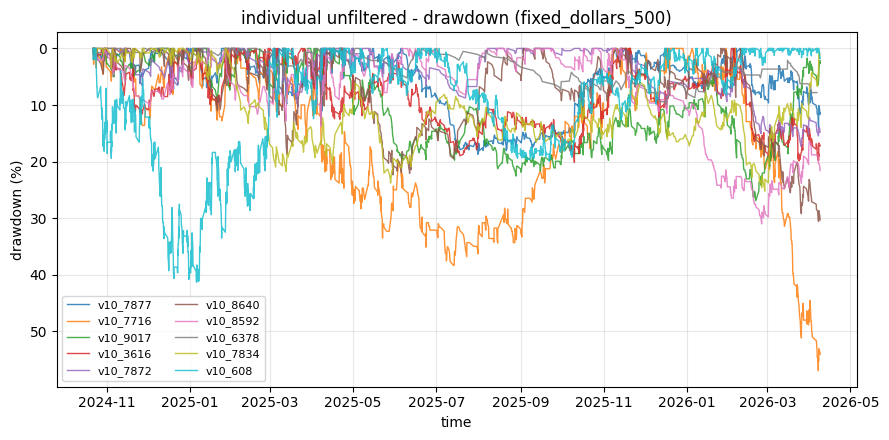

In [5]:
plot_indiv_dd(results_raw, 'fixed_dollars_500')

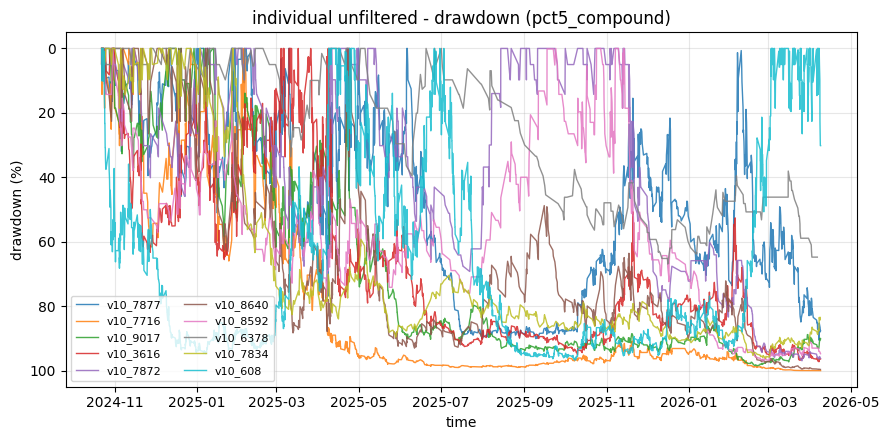

In [6]:
plot_indiv_dd(results_raw, 'pct5_compound')